# XGBoosted + Prophet Hybrid Model

We saw in 1modeling_experiments.ipynb that XGBoost+Prophet performed well. The margins between Prophet and the XGBoosted Prophet models were quite slim. We do some feature engineering and hyperparameter tuning to see if we can improve performance.

## Import Packages

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance

In [29]:
# this is the time series split we will work with
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

**Warning:** One should be cautious about temporal leakage. Our goal is to forecast 14 days out into the future. So, we should not use something like a lagged feature by 7 days. The reason is that when we are forecasting the 8th day out and onwards, we would be using a feature that is still outside of our scope. In other words, we should really avoid any lagged features of <14 days for our purposes.

## First Run

In [30]:
def create_features(df):
    # create time series features based on time series index.
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    # features to handly cyclic behavior
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


In [31]:
## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [32]:
def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary columns
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Remove overlapping columns to avoid join errors
    overlap = wd.columns.intersection(df.columns)
    wd = wd.drop(columns=overlap)
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df

In [33]:
date_range = pd.date_range(start="2020-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

In [34]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

In [35]:
def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

In [36]:
def add_new_lags(df, x):
    # lags
    target_map = df[x].to_dict()
    df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag17'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag18'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag19'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag20'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag21'] = (df.index - pd.Timedelta('16 days')).map(target_map)

    df[f'{x}lag30'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag365'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag730'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    return df

In [37]:
FEATURES = ['apparent_temperature_min_lag30',
            'apparent_temperature_min_lag60',
            'apparent_temperature_min_lag120',
            'apparent_temperature_min_lag365',
            'apparent_temperature_min_lag730',
            'dayofyear', 'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
            'temperature_2m_max_lag60', 
            'is_federal_holiday', 
            'lag15', 'lag16', 'lag30', 'lag60', 'lag90', 'lag120', 'lag150', 
            'lag180', 
            'lag362', 'lag363', 'lag364', 'lag365', 'lag366', 'lag367',
            'residualslag15', 'residualslag16', 'residualslag17',
            'residualslag18', 'residualslag19', 'residualslag20', 'residualslag21',
            'residualslag30', 'residualslag365', 'residualslag730', 
            'trend', 'yhat_lower', 'yhat_upper', 
            ]

In [38]:
params = {'objective': 'reg:squarederror',
         'eval_metric': 'rmse',
         'booster': 'gbtree',
         'base_score': 0.5, 
         'n_estimators': 200, 
        #  'min_child_weight': 6, 
         'learning_rate': 0.01,
        # 'max_depth': 6, 
        # 'subsample': 1,
        # 'colsample_bytree': 0.96,
        # 'colsample_bylevel': 0.6, 
        # 'colsample_bynode': 0.9, 
        # 'reg_alpha': 2.2, 
        # 'gamma': 100, 
        # 'reg_lambda': 0.18,
        #  'early_stopping_rounds': 100, 
        }

In [39]:
save = rs['ds'].copy().values
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)
rs['ds']=save
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')
rs.columns

Index(['y', 'ds', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag1', 'apparent_temperature_min_lag7',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_t

In [40]:
results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):
    # Split the dataset into training and testing sets
    train = rs.iloc[train_index]
    test = rs.iloc[test_index]
    
    # Fit Prophet on the training data
    model = Prophet(holidays=holidays)
    model.add_country_holidays(country_name='US')
    model.fit(train)
    
    # Make predictions on the training set to calculate residuals
    train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
    train_forecast = model.predict(train_future)
    
    # Calculate residuals (actual - predicted) on the training data
    train_residuals = train['y'].values - train_forecast['yhat'].values
    
#    train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    # Build a new DataFrame of residuals
    residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })

    train.loc[:, 'residuals'] = train_residuals
    add_new_lags(train, 'residuals')

    train.loc[:, 'trend'] = train_forecast['trend'].values
    train.loc[:, 'yhat_lower'] = train_forecast['yhat_lower'].values
    train.loc[:, 'yhat_upper'] = train_forecast['yhat_upper'].values
    
    X_train_residuals = train[FEATURES]
    y_train_residuals = residuals_df['y']
    
    xgb_model = xgb.XGBRegressor(**params)
    xgb_model.fit(X_train_residuals, y_train_residuals)

    test.loc[:, 'residuals'] = np.nan    
    dummy = pd.concat([X_train_residuals, test], axis=0)  # row-wise   
    add_new_lags(dummy,'residuals')

    test = dummy.iloc[test_index]

    # Forecast using Prophet on the test set
    future = model.make_future_dataframe(periods=len(test), freq='D')
    prophet_forecast = model.predict(future)

    
    # Predict residuals using XGBoost for the test set
    test.loc[:, 'trend'] = prophet_forecast[-len(test):]['trend'].values
    test.loc[:, 'yhat_lower'] = prophet_forecast[-len(test):]['yhat_lower'].values
    test.loc[:, 'yhat_upper'] = prophet_forecast[-len(test):]['yhat_upper'].values
    
    X_test = test[FEATURES]  # Features for the test set
    xgb_residual_preds = xgb_model.predict(X_test)
    
    
    
    # Combine Prophet's forecast and XGBoost's residual prediction
    y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
    y_true = test['y'].values
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # Store the results for this fold
    results.append({'fold': i, 'rmse': rmse, 'mape': mape})
    
    
    # # Uncomment code below if you want to have plots on feature importance. I'll leave it commented out for obvious reasons.
    # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
    # plot_importance(xgb_model, ax=ax1, importance_type='gain')
    # ax1.set_title('Gain-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax2, importance_type='weight')
    # ax2.set_title('Split-based Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax3, importance_type='cover')
    # ax3.set_title('Cover Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
    # ax4.set_title('Total Gain Importance', fontsize=12)

    # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
    # ax5.set_title('Total Cover Importance', fontsize=12)

    plt.show()

# Convert the results into a DataFrame
prophet_xgb_results_df = pd.DataFrame(results)
mean_rmse = prophet_xgb_results_df['rmse'].mean()
mean_mape = prophet_xgb_results_df['mape'].mean()
prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

09:37:51 - cmdstanpy - INFO - Chain [1] start processing
09:37:51 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_74710/1455926325.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train.loc[:, 'residuals'] = train_residuals
/var/folders/ry/m6r2ndwd10bdv8tvww5hr2680000gn/T/ipykernel_74710/1320145536.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
/var/folders/ry/m6r2ndwd10b

In [41]:
train.columns

Index(['y', 'ds', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag1', 'apparent_temperature_min_lag7',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_t

In [42]:
prophet_xgb_results_df

,fold,rmse,mape
0,0,11.697049,0.151670
1,1,13.113949,0.217993
2,2,9.699317,0.151066
3,3,15.040204,0.152789
4,4,13.379214,0.116336
5,5,16.485612,0.158459
6,6,12.991191,0.123588
7,7,11.134158,0.093057
8,8,15.096764,0.179023
9,9,11.653424,0.118434


# Examining Residuals Data

In [44]:
model = Prophet(holidays=holidays)
model.add_country_holidays(country_name='US')
model.fit(rs)
rs_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
rs_forecast = model.predict(rs_future)
    
rs_residuals = rs['y'].values - rs_forecast['yhat'][:len(rs)].values.astype(int)
    

09:38:51 - cmdstanpy - INFO - Chain [1] start processing
09:38:51 - cmdstanpy - INFO - Chain [1] done processing


In [45]:
residuals = pd.DataFrame({'ds': rs['ds'],  # Use the 'ds' column from the original `rs` dataframe
    'y': rs_residuals  # Use the computed residuals
})
residuals['y'].describe()

count    1886.000000
mean        0.503181
std        13.887106
min       -49.000000
25%        -9.000000
50%         0.000000
75%         9.000000
max        49.000000
Name: y, dtype: float64

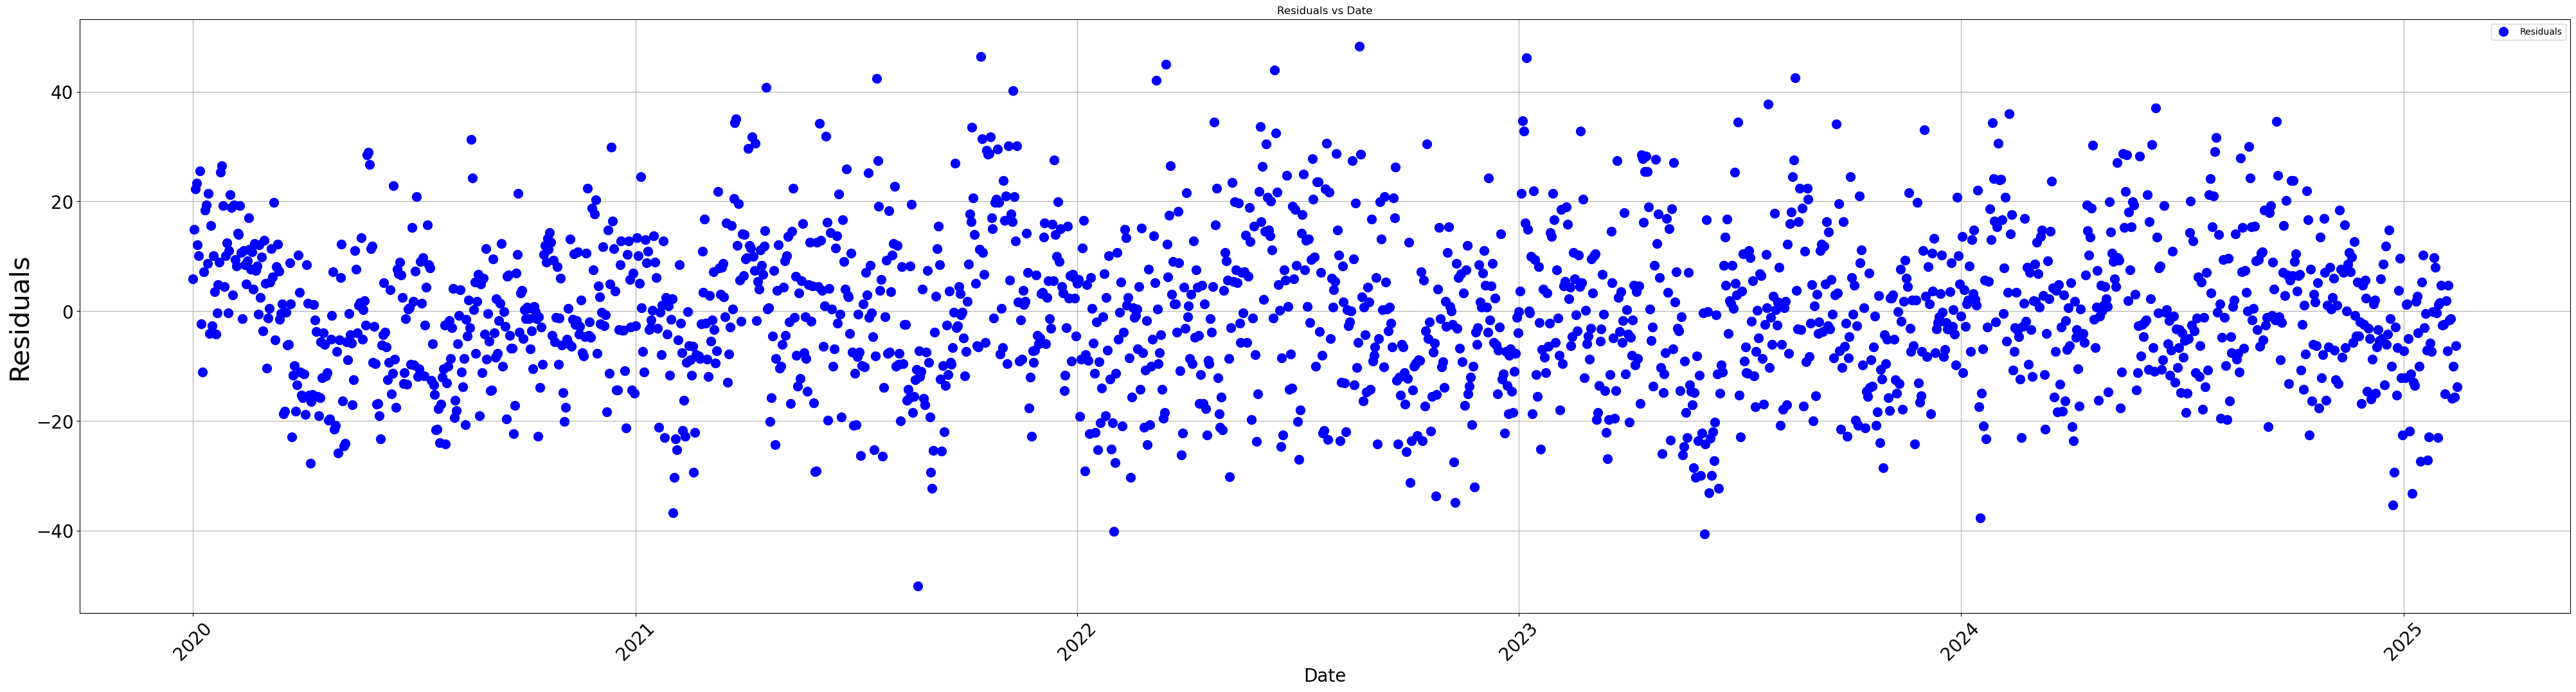

In [46]:
plt.figure(figsize=(50, 12))
plt.plot(residuals_df['ds'], residuals_df['y'], marker='o', linestyle='', color='b', label='Residuals', markersize = 10)
plt.title('Residuals vs Date')
plt.xlabel('Date', size =20)
plt.ylabel('Residuals', size =30)
plt.grid(True)
plt.xticks(rotation=45, size= 20)  # Rotate x-axis labels for better readability
plt.yticks(size=20)
plt.legend()
plt.show()

In [47]:
import plotly.graph_objects as go
import pandas as pd

window_size = 30

residuals_df['rolling_mean'] = residuals_df['y'].rolling(window=window_size).mean()
residuals_df['rolling_variance'] = residuals_df['y'].rolling(window=window_size).var()
residuals_df['y_365_days_ago'] = residuals_df['y'].shift(365)
residuals_df['y_15_days_ago'] = residuals_df['y'].shift(15)



fig = go.Figure()

fig.add_trace(go.Scatter(
    x=residuals_df['ds'],
    y=residuals_df['y'],
    mode='markers',
    name='Residuals',
    marker=dict(size=5, color='blue') 
))

# fig.add_trace(go.Scatter(
#     x=residuals_df['ds'],
#     y=residuals_df['rolling_mean'],
#     mode='lines',
#     name=f'Rolling Mean (window={window_size})',
#     line=dict(color='red', width=3)
# ))

# fig.add_trace(go.Scatter(
#     x=residuals_df['ds'],
#     y=residuals_df['rolling_variance'],
#     mode='lines',
#     name=f'Rolling Variance (window={window_size})',
#     line=dict(color='green', width=3)
# ))

# Plot 365 days ago actuals as orange dots
fig.add_trace(go.Scatter(
    x=residuals_df['ds'],
    y=residuals_df['y_365_days_ago'],
    mode='markers',  # Change mode to 'markers' to plot dots
    name='365 Days Ago Actuals',
    marker=dict(color='orange', size=4)  # Customize the dot color and size
))

# fig.add_trace(go.Scatter(
#     x=residuals_df['ds'],
#     y=residuals_df['y_15_days_ago'],
#     mode='markers',  # Change mode to 'markers' to plot dots
#     name='15 Days Ago Actuals',
#     marker=dict(color='green', size=4)  # Customize the dot color and size
# ))


# Update layout
fig.update_layout(
    title='Residuals and 365 Days Ago Actuals vs Date',
    xaxis_title='Date',
    yaxis_title='Residuals',
    xaxis=dict(tickangle=45, tickfont=dict(size=20)),
    yaxis=dict(tickfont=dict(size=20)),
    legend=dict(font=dict(size=10),  # Further reduced legend size
                x=0.8, y=0.95,  # Legend position
                traceorder='normal',
                bgcolor='rgba(255, 255, 255, 0.7)',  # Background for legend
                bordercolor='Black', borderwidth=1),
    width=1000,  # Width of the plot
    height=600,  # Height of the plot
    margin=dict(l=100, r=100, t=100, b=100), 
    template='plotly'
)

# Show the figure
fig.show()

# window_size = 730
# residuals_df['rolling_mean'] = residuals_df['y'].rolling(window=window_size).mean()
# residuals_df['rolling_variance'] = residuals_df['y'].rolling(window=window_size).var()

# plt.figure(figsize=(60, 12))

# plt.plot(residuals_df['ds'], residuals_df['y'], marker='o', linestyle='', color='b', label='Residuals', markersize=10)
# plt.plot(residuals_df['ds'], residuals_df['rolling_mean'], color='r', label=f'Rolling Mean (window={window_size})', linewidth=3)
# plt.plot(residuals_df['ds'], residuals_df['rolling_variance'], color='g', label=f'Rolling Variance (window={window_size})', linewidth=3)

# # Add title and labels
# plt.title('Residuals, Rolling Mean, and Rolling Variance vs Date')
# plt.xlabel('Date', size=20)
# plt.ylabel('Residuals', size=30)
# plt.grid(True)
# plt.xticks(rotation=45, size=20)  # Rotate x-axis labels for better readability
# plt.yticks(size=20)

# # Show legend
# plt.legend()

# # Show plot
# plt.show()

/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




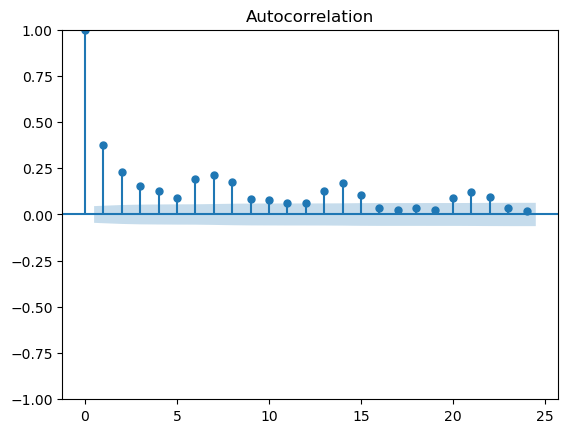

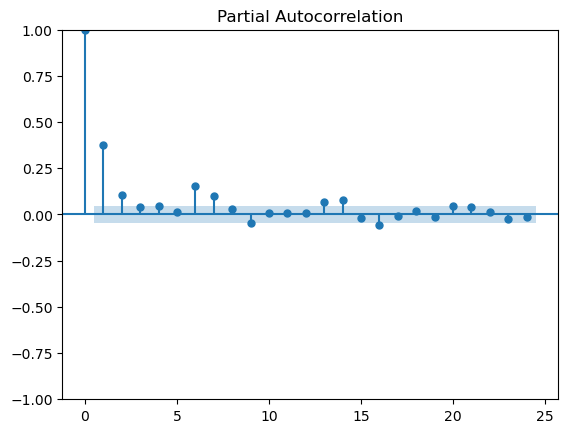

In [48]:
import matplotlib.pyplot as plt
import statsmodels.api as sm


sm.graphics.tsa.plot_acf(residuals_df['y'], lags=24)
sm.graphics.tsa.plot_pacf(residuals_df['y'], lags=24)
plt.show()

# Optuna Hyperparameter Tuning


In the XGBoost + Prophet hybrid model, we can tune a lot of parameters and also do a lot of feature engineering. For this reasoning, we shall use Optuna. Optuna also has the added benefit that it can record its studies in a .db so that future studies can piggyback off of old studies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import xgboost as xgb
from xgboost import plot_importance
import optuna
from optuna.exceptions import TrialPruned

In [2]:
# we import the data and clean it for future use
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 
# mark cutoff dates, and also rename columns
rs = rs[rs['created_date']<'2025-03-01']
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

The next cell block is a copy and paste of the functions from the first part of this notebook. We have this cellblock here so that we can run code in this section without having to rerun the previous sections.

In [3]:
def create_features(df):
    # create time series features based on time series index.
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

def add_cyclic(df):
    # features to handly cyclic behavior
    target_map = df['y'].to_dict()
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    return df

def add_lags(df):
    # lags
    target_map = df['y'].to_dict()
    df['lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    return df

def add_seasonal_lags(df):
    # lags of various lengths for different levels of seasonality
    target_map = df['y'].to_dict()
    df['lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)

    df['lag362'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag363'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag364'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag366'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag367'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    
    df['lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    df['lag1095'] = (df.index - pd.Timedelta('1095 days')).map(target_map)
    df['lag1460'] = (df.index - pd.Timedelta('1460 days')).map(target_map)
    df['lag1825'] = (df.index - pd.Timedelta('1825 days')).map(target_map)
    return df

def add_moving_averages(df):
    df = df.copy()
    df = df.sort_index()
    
    # Moving averages (using previous values only)
    # Must shift by 14 days because we do not want to let there be temporal leakage in our evaluations
    df['ma7'] = df['y'].shift(14).rolling(window=7).mean()
    df['ma30'] = df['y'].shift(14).rolling(window=30).mean()
    df['ma60'] = df['y'].shift(14).rolling(window=60).mean()
    df['ma90'] = df['y'].shift(14).rolling(window=90).mean()
    df['ma120'] = df['y'].shift(14).rolling(window=120).mean()
    df['ma150'] = df['y'].shift(14).rolling(window=150).mean()
    df['ma180'] = df['y'].shift(14).rolling(window=180).mean()
    df['ma365'] = df['y'].shift(14).rolling(window=365).mean()
    
    return df


## Add weather data.

import requests
import pandas as pd

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2025-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")


def add_weather_data(df, wd):
    df = df.copy()
    wd = wd.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    wd.index = pd.to_datetime(wd.index)
    
    # Drop unnecessary columns
    if "time" in wd.columns:
        wd = wd.drop(columns=["time"])
    
    # Remove overlapping columns to avoid join errors
    overlap = wd.columns.intersection(df.columns)
    wd = wd.drop(columns=overlap)
    
    # Join on date index
    df = df.join(wd, how="left")
    
    return df

def add_more_weather_feature(df):
    target_map = df['apparent_temperature_min'].to_dict()
    df['apparent_temperature_min_lag1'] = (df.index - pd.Timedelta('1 days')).map(target_map)
    df['apparent_temperature_min_lag7'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['apparent_temperature_min_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['apparent_temperature_min_lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df['apparent_temperature_min_lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df['apparent_temperature_min_lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df['apparent_temperature_min_lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df['apparent_temperature_min_lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df['apparent_temperature_min_lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df['apparent_temperature_min_lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df['apparent_temperature_min_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['apparent_temperature_min_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['apparent_temperature_min_lag90'] = (df.index - pd.Timedelta('90 days')).map(target_map)
    df['apparent_temperature_min_lag120'] = (df.index - pd.Timedelta('120 days')).map(target_map)
    df['apparent_temperature_min_lag150'] = (df.index - pd.Timedelta('150 days')).map(target_map)
    df['apparent_temperature_min_lag180'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    df['apparent_temperature_min_lag210'] = (df.index - pd.Timedelta('210 days')).map(target_map)
    df['apparent_temperature_min_lag240'] = (df.index - pd.Timedelta('240 days')).map(target_map)
    df['apparent_temperature_min_lag270'] = (df.index - pd.Timedelta('270 days')).map(target_map)
    df['apparent_temperature_min_lag300'] = (df.index - pd.Timedelta('300 days')).map(target_map)
    df['apparent_temperature_min_lag330'] = (df.index - pd.Timedelta('330 days')).map(target_map)
    df['apparent_temperature_min_lag360'] = (df.index - pd.Timedelta('360 days')).map(target_map)
    df['apparent_temperature_min_lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['apparent_temperature_min_lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)

    target_map = df['temperature_2m_max'].to_dict()
    df['temperature_2m_max_lag14'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['temperature_2m_max_lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['temperature_2m_max_lag60'] = (df.index - pd.Timedelta('60 days')).map(target_map)

    return df


date_range = pd.date_range(start="2020-01-01", end="2025-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

from pandas.tseries.holiday import USFederalHolidayCalendar

def add_federal_holidays(df, custom_holidays=None):
    df = df.copy()
    
    # Ensure datetime index
    df.index = pd.to_datetime(df.index)
    
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    if custom_holidays:
        for d in custom_holidays:
            if len(d) == 5:  # MM-DD format handling
                years = df.index.year.unique()
                for y in years:
                    holidays = holidays.append(pd.to_datetime([f"{y}-{d}"]))
            else:  # YYYY-MM-DD format handling
                holidays = holidays.append(pd.to_datetime([d]))
    
    holidays = holidays.drop_duplicates().sort_values()
    
    df["is_federal_holiday"] = df.index.isin(holidays).astype(int)
    
    return df

def add_law_flag(df, law_name: str, start_date: str):
    # Adds a binary column to indicate when a new law is active.
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    start_dt = pd.to_datetime(start_date)
    # Create binary column: 1 if date >= start_date, else 0
    df[law_name] = (df.index >= start_dt).astype(int)
    
    return df

def add_new_lags(df, x):
    # lags
    target_map = df[x].to_dict()
    df[f'{x}lag15'] = (df.index - pd.Timedelta('15 days')).map(target_map)
    df[f'{x}lag16'] = (df.index - pd.Timedelta('16 days')).map(target_map)
    df[f'{x}lag17'] = (df.index - pd.Timedelta('17 days')).map(target_map)
    df[f'{x}lag18'] = (df.index - pd.Timedelta('18 days')).map(target_map)
    df[f'{x}lag19'] = (df.index - pd.Timedelta('19 days')).map(target_map)
    df[f'{x}lag20'] = (df.index - pd.Timedelta('20 days')).map(target_map)
    df[f'{x}lag21'] = (df.index - pd.Timedelta('21 days')).map(target_map)

    df[f'{x}lag30'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df[f'{x}lag365'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df[f'{x}lag730'] = (df.index - pd.Timedelta('730 days')).map(target_map)
    return df

In [4]:
ALL_FEATURES = {'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear', 'dayofweek_sin', 'dayofweek_cos',
       'month_sin', 'month_cos', 'lag15', 'lag16', 'lag30', 'lag60', 'lag90',
       'lag120', 'lag150', 'lag180', 'lag362', 'lag363', 'lag364', 'lag365',
       'lag366', 'lag367', 'lag730', 'lag1095', 'lag1460', 'lag1825', 'ma7',
       'ma30', 'ma60', 'ma90', 'ma120', 'ma150', 'ma180', 'ma365',
       'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'apparent_temperature_mean', 'precipitation_sum', 'snowfall_sum',
       'apparent_temperature_min_lag1', 'apparent_temperature_min_lag7',
       'apparent_temperature_min_lag14', 'apparent_temperature_min_lag15',
       'apparent_temperature_min_lag16', 'apparent_temperature_min_lag17',
       'apparent_temperature_min_lag18', 'apparent_temperature_min_lag19',
       'apparent_temperature_min_lag20', 'apparent_temperature_min_lag21',
       'apparent_temperature_min_lag30', 'apparent_temperature_min_lag60',
       'apparent_temperature_min_lag90', 'apparent_temperature_min_lag120',
       'apparent_temperature_min_lag150', 'apparent_temperature_min_lag180',
       'apparent_temperature_min_lag210', 'apparent_temperature_min_lag240',
       'apparent_temperature_min_lag270', 'apparent_temperature_min_lag300',
       'apparent_temperature_min_lag330', 'apparent_temperature_min_lag360',
       'apparent_temperature_min_lag365', 'apparent_temperature_min_lag730',
       'temperature_2m_max_lag14', 'temperature_2m_max_lag30',
       'temperature_2m_max_lag60', 'is_federal_holiday', 'Trash_Law',
       'New_Trash_Law', 'Rat_Mitigation_Zone', 'Rat_Czar_Appointed',
       'residuals', 'residualslag15', 'residualslag16', 'residualslag17',
       'residualslag18', 'residualslag19', 'residualslag20', 'residualslag21',
       'residualslag30', 'residualslag365', 'residualslag730', 'trend',
       'yhat_lower', 'yhat_upper'}

# ALL_FEATURES =['lag60', 'ma7', 'yhat_lower', 'temperature_2m_max_lag60', 'dayofweek', 
#                'apparent_temperature_min_lag360', 'dayofyear', 'apparent_temperature_min_lag120', 'Trash_Law', 'quarter', 'month_sin', 'ma60', 'Rat_Mitigation_Zone', 'temperature_2m_max_lag30', 'lag730', 'apparent_temperature_max', 'apparent_temperature_min', 
#                'residualslag365', 'lag366', 'lag363', 'lag364', 'apparent_temperature_min_lag180', 
#                'apparent_temperature_min_lag240', 'apparent_temperature_min_lag18', 'apparent_temperature_min_lag90', 'dayofweek_cos']

In [5]:
save = rs['ds'].copy().values
rs = rs.set_index('ds')
rs.index = pd.to_datetime(rs.index)
rs['ds']=save
rs = create_features(rs)
rs = add_cyclic(rs)
rs = add_lags(rs)
rs = add_seasonal_lags(rs)
rs = add_moving_averages(rs)
rs = add_weather_data(rs,wd)
rs = add_more_weather_feature(rs)
rs = add_federal_holidays(rs, custom_holidays = ['12-31'])
rs = add_law_flag(rs, law_name='Trash_Law', start_date = '2024-03-01')
rs = add_law_flag(rs, law_name = 'New_Trash_Law', start_date = '2024-11-01')
rs = add_law_flag(rs, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
rs = add_law_flag(rs, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')
rs

,y,ds,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,dayofweek_sin,...,apparent_temperature_min_lag365,apparent_temperature_min_lag730,temperature_2m_max_lag14,temperature_2m_max_lag30,temperature_2m_max_lag60,is_federal_holiday,Trash_Law,New_Trash_Law,Rat_Mitigation_Zone,Rat_Czar_Appointed
ds,,,,,,,,,,,,,,,,,,,,,
2020-01-01,17,2020-01-01,2,1,1,2020,1,1,1,0.974928,...,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0
2020-01-02,40,2020-01-02,3,1,1,2020,2,2,1,0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-03,41,2020-01-03,4,1,1,2020,3,3,1,-0.433884,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-04,25,2020-01-04,5,1,1,2020,4,4,1,-0.974928,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
2020-01-05,17,2020-01-05,6,1,1,2020,5,5,1,-0.781831,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,57,2025-02-24,0,1,2,2025,55,24,9,0.000000,...,-11.1,-10.8,0.2,-2.2,-0.2,0,1,1,1,1
2025-02-25,61,2025-02-25,1,1,2,2025,56,25,9,0.781831,...,-6.9,-8.1,-0.4,4.1,2.5,0,1,1,1,1
2025-02-26,61,2025-02-26,2,1,2,2025,57,26,9,0.974928,...,-4.1,-7.1,0.6,2.0,7.5,0,1,1,1,1


In [6]:
import logging
logging.getLogger("cmdstanpy").disabled = True

In [7]:
import optuna

def objective(trial):
    print("Trial starting:", trial.number)

    # Prophet Hyperparameters
    prophet_params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.1, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.1, 10, log=True),
        "holidays_prior_scale": trial.suggest_float("holidays_prior_scale", 0.01, 10, log=True),
    }

    # XGBoost Hyperparameters
    xgb_params = {"device": "cuda",
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 1, log=True),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.01, 10, log=True),
        "objective": "reg:squarederror",
        "random_state": 42
    }


    # Feature Selection
    selected_features = []

    for feature in ALL_FEATURES:
        if trial.suggest_categorical(feature, [True, False]):
            selected_features.append(feature)


    # prevent Optuna from accidentally picking no features
    if len(selected_features) == 0: 
        selected_features.append("trend")


    results = []

    for i, (train_index, test_index) in enumerate(tscv.split(rs)):

        train = rs.iloc[train_index].copy()
        test = rs.iloc[test_index].copy()

        model = Prophet(**prophet_params, holidays=holidays)
        model.add_country_holidays(country_name='US')
        model.fit(train)

        train_future = model.make_future_dataframe(periods=0, freq='D')
        train_forecast = model.predict(train_future)

        train_residuals = train['y'].values - train_forecast['yhat'].values

        residuals_df = pd.DataFrame({'ds': train['ds'],'y': train_residuals})

        train['residuals'] = train_residuals

        add_new_lags(train, 'residuals')

        train['trend'] = train_forecast['trend'].values
        train['yhat_lower'] = train_forecast['yhat_lower'].values
        train['yhat_upper'] = train_forecast['yhat_upper'].values

        X_train_residuals = train[selected_features]
        y_train_residuals = residuals_df['y']

        # Train XGBoost
        xgb_model = xgb.XGBRegressor(**xgb_params)
        xgb_model.fit(X_train_residuals, y_train_residuals)

        # Prepare Test Data
        test['residuals'] = np.nan # need to add this otherwise it won't run

        dummy = pd.concat([train, test], axis=0)

        add_new_lags(dummy, 'residuals') # need to add the lags that test can actually see

        test = dummy.iloc[test_index].copy() # cut out the test set again

        # Prophet Forecast
        future = model.make_future_dataframe(periods=len(test), freq='D')
        prophet_forecast = model.predict(future)

        # add outputs of Prophet for use in the XGBoost model
        test.loc[:, 'trend'] = prophet_forecast[-len(test):]['trend'].values
        test.loc[:, 'yhat_lower'] = prophet_forecast[-len(test):]['yhat_lower'].values
        test.loc[:, 'yhat_upper'] = prophet_forecast[-len(test):]['yhat_upper'].values

        X_test = test[selected_features]

        xgb_residual_preds = xgb_model.predict(X_test)

        y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds
        y_true = test['y'].values

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        results.append(rmse)

        # # Report intermediate result to Optuna
        # trial.report(rmse, step=i)

        # # Check if trial should be pruned
        # if trial.should_prune():
        #     raise TrialPruned()

    return np.mean(results)

In [ ]:
splits = 26 # from among 7, 13, 26, 

if splits == 26:
    # this is the time series split we will work with
    tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=splits, test_size=14)

    study = optuna.create_study(
        direction="minimize",
        study_name="hybrid_model_feature_parameter_search",
        storage="sqlite:///xgbprophet_model26.db",
        load_if_exists=True
    )
    study.optimize(objective, n_trials=100000, n_jobs=-1)

    print("Best RMSE:", study.best_value)
    print("Best params:", study.best_params)


    best_features = [
    f for f in ALL_FEATURES
    if study.best_params.get(f, False)]

    print("Selected Features:")
    print(best_features)

if splits == 13:
    # this is the time series split we will work with
    tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=splits, test_size=14)

    study = optuna.create_study(
        direction="minimize",
        study_name="hybrid_model_feature_parameter_search",
        storage="sqlite:///xgbprophet_model13.db",
        load_if_exists=True
    )
    study.optimize(objective, n_trials=2, n_jobs=-1)

    print("Best RMSE:", study.best_value)
    print("Best params:", study.best_params)


    best_features = [
    f for f in ALL_FEATURES
    if study.best_params.get(f, False)]

    print("Selected Features:")
    print(best_features)

if splits == 7:
    # this is the time series split we will work with
    tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=splits, test_size=14)

    study = optuna.create_study(
        direction="minimize",
        study_name="hybrid_model_feature_parameter_search",
        storage="sqlite:///xgbprophet_model7.db",
        load_if_exists=True
    )
    study.optimize(objective, n_trials=2, n_jobs=-1)

    print("Best RMSE:", study.best_value)
    print("Best params:", study.best_params)


    best_features = [
    f for f in ALL_FEATURES
    if study.best_params.get(f, False)]

    print("Selected Features:")
    print(best_features)

[I 2026-03-12 10:13:44,942] Using an existing study with name 'hybrid_model_feature_parameter_search' instead of creating a new one.


Trial starting: 50
Trial starting: 51
Trial starting: 55
Trial starting: 49
Trial starting: 57
Trial starting: 53
Trial starting: 59
Trial starting: 52
Trial starting: 56
Trial starting: 54
Trial starting: 61
Trial starting: 60
Trial starting: 58
Trial starting: 62
Trial starting: 64
Trial starting: 63


[I 2026-03-12 10:24:51,041] Trial 59 finished with value: 11.940129618271984 and parameters: {'changepoint_prior_scale': 0.2783454556483858, 'seasonality_prior_scale': 9.48412330353468, 'holidays_prior_scale': 0.18639872711310024, 'n_estimators': 491, 'max_depth': 4, 'learning_rate': 0.021905350788645903, 'subsample': 0.7333786782076348, 'colsample_bytree': 0.5272912574346698, 'gamma': 2.7681246735253104, 'min_child_weight': 9, 'reg_lambda': 5.52434272344213, 'reg_alpha': 0.02514896457828109, 'lag367': True, 'apparent_temperature_min_lag1': False, 'Rat_Mitigation_Zone': True, 'is_federal_holiday': True, 'dayofyear': True, 'apparent_temperature_min_lag30': False, 'apparent_temperature_min_lag365': True, 'lag362': False, 'residualslag16': True, 'ma90': True, 'temperature_2m_mean': False, 'lag180': False, 'apparent_temperature_min_lag300': True, 'lag730': True, 'apparent_temperature_min_lag270': True, 'month_cos': True, 'year': True, 'residualslag17': True, 'lag60': False, 'apparent_tempe

Trial starting: 65
Trial starting: 66


[I 2026-03-12 10:26:16,272] Trial 57 finished with value: 11.822871319437981 and parameters: {'changepoint_prior_scale': 0.30465385200655837, 'seasonality_prior_scale': 9.134002576082258, 'holidays_prior_scale': 0.185856217190592, 'n_estimators': 505, 'max_depth': 4, 'learning_rate': 0.020681406638478693, 'subsample': 0.7225138714764172, 'colsample_bytree': 0.3986843252437656, 'gamma': 2.7235960386149745, 'min_child_weight': 10, 'reg_lambda': 4.873801827456304, 'reg_alpha': 0.015588461484408076, 'lag367': True, 'apparent_temperature_min_lag1': False, 'Rat_Mitigation_Zone': True, 'is_federal_holiday': True, 'dayofyear': True, 'apparent_temperature_min_lag30': False, 'apparent_temperature_min_lag365': True, 'lag362': False, 'residualslag16': True, 'ma90': True, 'temperature_2m_mean': False, 'lag180': False, 'apparent_temperature_min_lag300': True, 'lag730': True, 'apparent_temperature_min_lag270': True, 'month_cos': True, 'year': True, 'residualslag17': True, 'lag60': False, 'apparent_te

...

[I 2026-03-12 20:27:46,185] Trial 113 finished with value: 12.377388378140235 and parameters: {'changepoint_prior_scale': 0.20565144184856027, 'seasonality_prior_scale': 8.561055544295668, 'holidays_prior_scale': 2.0783834551060236, 'n_estimators': 642, 'max_depth': 4, 'learning_rate': 0.04443642608424122, 'subsample': 0.7000136047645663, 'colsample_bytree': 0.3411200965760205, 'gamma': 2.3823930711413004, 'min_child_weight': 7, 'reg_lambda': 1.9541606460443892, 'reg_alpha': 0.017177131038555175, 'lag367': True, 'apparent_temperature_min_lag1': True, 'Rat_Mitigation_Zone': True, 'is_federal_holiday': True, 'dayofyear': False, 'apparent_temperature_min_lag30': False, 'apparent_temperature_min_lag365': True, 'lag362': True, 'residualslag16': True, 'ma90': False, 'temperature_2m_mean': False, 'lag180': True, 'apparent_temperature_min_lag300': True, 'lag730': False, 'apparent_temperature_min_lag270': False, 'month_cos': True, 'year': False, 'residualslag17': True, 'lag60': False, 'apparent

Trial starting: 123


[I 2026-03-12 20:28:49,972] Trial 109 finished with value: 11.916367154062875 and parameters: {'changepoint_prior_scale': 0.19125273583881566, 'seasonality_prior_scale': 8.47173713444558, 'holidays_prior_scale': 2.332579813049586, 'n_estimators': 619, 'max_depth': 6, 'learning_rate': 0.014867761032531252, 'subsample': 0.6991628986049441, 'colsample_bytree': 0.4457889262420133, 'gamma': 2.5160034567368172, 'min_child_weight': 2, 'reg_lambda': 2.518556856138905, 'reg_alpha': 0.017011855604996417, 'lag367': True, 'apparent_temperature_min_lag1': True, 'Rat_Mitigation_Zone': True, 'is_federal_holiday': True, 'dayofyear': False, 'apparent_temperature_min_lag30': False, 'apparent_temperature_min_lag365': True, 'lag362': True, 'residualslag16': True, 'ma90': False, 'temperature_2m_mean': False, 'lag180': True, 'apparent_temperature_min_lag300': True, 'lag730': False, 'apparent_temperature_min_lag270': False, 'month_cos': True, 'year': False, 'residualslag17': True, 'lag60': False, 'apparent_t

Trial starting: 124


[I 2026-03-12 20:29:19,315] Trial 114 finished with value: 12.275796427328011 and parameters: {'changepoint_prior_scale': 0.11793464880733491, 'seasonality_prior_scale': 8.602152088634694, 'holidays_prior_scale': 1.9165245173345353, 'n_estimators': 642, 'max_depth': 4, 'learning_rate': 0.01510667648790564, 'subsample': 0.7548606196442855, 'colsample_bytree': 0.34178122384115694, 'gamma': 2.4760418891335103, 'min_child_weight': 7, 'reg_lambda': 6.311733633082588, 'reg_alpha': 0.01628840712330232, 'lag367': True, 'apparent_temperature_min_lag1': True, 'Rat_Mitigation_Zone': True, 'is_federal_holiday': True, 'dayofyear': False, 'apparent_temperature_min_lag30': False, 'apparent_temperature_min_lag365': True, 'lag362': True, 'residualslag16': True, 'ma90': False, 'temperature_2m_mean': False, 'lag180': True, 'apparent_temperature_min_lag300': True, 'lag730': True, 'apparent_temperature_min_lag270': False, 'month_cos': True, 'year': True, 'residualslag17': True, 'lag60': False, 'apparent_te

In [ ]:
print(best_features)

['residualslag19', 'apparent_temperature_min_lag90', 'apparent_temperature_min_lag21', 'apparent_temperature_min_lag240', 'temperature_2m_max_lag60', 'apparent_temperature_min_lag19', 'lag366', 'Rat_Mitigation_Zone', 'apparent_temperature_min_lag180', 'apparent_temperature_min_lag15', 'apparent_temperature_min_lag360', 'residualslag20', 'lag363', 'lag120', 'lag362', 'snowfall_sum', 'dayofyear', 'lag1095', 'apparent_temperature_min_lag120', 'month_cos', 'lag60', 'apparent_temperature_min_lag16', 'apparent_temperature_min_lag1', 'temperature_2m_max_lag30', 'ma60', 'apparent_temperature_min_lag210', 'apparent_temperature_min_lag20', 'residualslag365', 'apparent_temperature_min_lag30', 'temperature_2m_mean', 'yhat_upper', 'lag30', 'apparent_temperature_min_lag17', 'ma30', 'apparent_temperature_min', 'month_sin', 'is_federal_holiday', 'dayofmonth', 'residualslag18', 'apparent_temperature_min_lag14', 'lag367', 'lag180', 'lag364', 'temperature_2m_max', 'lag1825']


# Cross Validate if Hybrid Model Performs as well as Claimed


If the mean RMSE can beat 11.519154 consistently, then I would be convinced. However, depending on the complexity, this might not be ideal as a forecasting method.

In [ ]:
# # this is the time series split we will work with
# tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)


# # we import the data and clean it for future use
# rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_cleaned_rat_sightings.csv')
# rs['created_date'] = pd.to_datetime(rs['created_date']) 
# rs['closed_date'] = pd.to_datetime(rs['closed_date'])
# rs['resolution_action_updated_date'] = pd.to_datetime(rs['resolution_action_updated_date'])
# # mark cutoff dates, and also rename columns
# rs = rs[rs['created_date']<'2025-03-01']
# rs = rs[rs['created_date']>='2020-01-01']
# rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
# rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

In [ ]:
# FEATURES = ['apparent_temperature_min_lag30',
#             'apparent_temperature_min_lag60',
#             'apparent_temperature_min_lag120',
#             'apparent_temperature_min_lag365',
#             'precipitation_sum', 'snowfall_sum',
#             'apparent_temperature_min_lag730',
#             'weekly', 'yearly', 'yhat',
#             'dayofyear', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos',
#             'temperature_2m_max_lag30',
#             'temperature_2m_max_lag60',
#             'lag15', 'lag16', 'lag17', 'lag18', 'lag19', 'lag20', 'lag21',
#             'lag22', 'lag23', 'lag24', 'lag25', 'lag26', 'lag27', 'lag28',
#             'lag29', 'lag30',
#             ]

# params = {'objective': 'reg:squarederror',
#          'eval_metric': 'rmse',
#          'booster': 'gbtree',
#         # 'base_score': 0.5, 
#          'n_estimators': 100, 
#         # 'min_child_weight': 6, 
#          'learning_rate': 0.0001,
#         # 'max_depth': 4, 
#         #  'subsample': 1,
#         #  'colsample_bytree': 0.96,
#         #  'colsample_bylevel': 0.6, 
#         #  'colsample_bynode': 0.9, 
#         #  'reg_alpha': 2.2, 
#         #  'gamma': 100, 
#         #  'reg_lambda': 0.18,
#         #  'early_stopping_rounds': 100, 
#         }

In [ ]:
# results = []

# for i, (train_index, test_index) in enumerate(tscv.split(rs)):
#     # Split the dataset into training and testing sets
#     train = rs.iloc[train_index]
#     test = rs.iloc[test_index]
    
#     # Fit Prophet on the training data
#     model = Prophet(holidays=holidays)
#     model.add_country_holidays(country_name='US')
#     model.fit(train)
    
#     # Make predictions on the training set to calculate residuals
#     train_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
#     train_forecast = model.predict(train_future)
    
#     # Calculate residuals (actual - predicted) on the training data
#     train_residuals = train['y'].values - train_forecast['yhat'][:len(train)].values
    
#     # Build a new DataFrame of residuals
#     residuals_df = pd.DataFrame({'ds': train['ds'], 'y': train_residuals })
#     # Add the features I defined above
#     train = train.set_index('ds')
#     train.index = pd.to_datetime(train.index)
#     train = create_features(train)
#     train = add_cyclic(train)
#     train = add_lags(train)
#     train = add_seasonal_lags(train)
#     train = add_moving_averages(train)
#     train = add_weather_data(train,wd)
#     train = add_more_weather_feature(train)
#     train = add_federal_holidays(train, custom_holidays = ['12-31'])
#     train = add_law_flag(train, law_name='Trash_Law', start_date = '2024-03-01')
#     train = add_law_flag(train, law_name = 'New_Trash_Law', start_date = '2024-11-01')
#     train = add_law_flag(train, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
#     train = add_law_flag(train, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

        
#     for col in train_forecast.columns:
#         if col == 'ds':
#             continue
#         train[col] = train_forecast[col].values

#     X_train_residuals = train[FEATURES]
#     y_train_residuals = residuals_df['y']
    
#     xgb_model = xgb.XGBRegressor(**params)
#     xgb_model.fit(X_train_residuals, y_train_residuals)
    
#     # Add the features I defined above (I should probably define a new function to do this in one go...)
#     test_forecast = model.predict(test)
#     test = test.set_index('ds')
#     test.index = pd.to_datetime(test.index)
#     test = create_features(test)
#     test = add_cyclic(test)
#     test = add_lags(test)
#     test = add_seasonal_lags(test)
#     test = add_moving_averages(test)
#     test = add_weather_data(test,wd)
#     test = add_more_weather_feature(test)
#     test = add_federal_holidays(test, custom_holidays = ['12-31'])
#     test = add_law_flag(test, law_name='Trash_Law', start_date = '2024-03-01')
#     test = add_law_flag(test, law_name = 'New_Trash_Law', start_date = '2024-11-01')
#     test = add_law_flag(test, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
#     test = add_law_flag(test, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')


#     for col in test_forecast.columns:
#         if col == 'ds':
#             continue
#         test[col] = test_forecast[col].values

#     # Predict residuals using XGBoost for the test set
#     X_test = test[FEATURES]  # Features for the test set
#     xgb_residual_preds = xgb_model.predict(X_test)
    
#     # Forecast using Prophet on the test set
#     future = model.make_future_dataframe(periods=len(test), freq='D')
#     prophet_forecast = model.predict(future)
    
#     # Combine Prophet's forecast and XGBoost's residual prediction
    
#     # y_pred = prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds

#     y_pred = (prophet_forecast['yhat'][-len(test):].values + xgb_residual_preds).astype(int) # make integer valued predictions
#     y_true = test['y'].values
    
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     mape = mean_absolute_percentage_error(y_true, y_pred)
    
#     # Store the results for this fold
#     results.append({'fold': i, 'rmse': rmse, 'mape': mape})
#     print({'fold': i, 'rmse': rmse, 'mape': mape})
    
    
#     ## Uncomment code below if you want to have plots on feature importance. I'll leave it commented out for obvious reasons.
#     # fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 30))
#     # plot_importance(xgb_model, ax=ax1, importance_type='gain')
#     # ax1.set_title('Gain-based Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax2, importance_type='weight')
#     # ax2.set_title('Split-based Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax3, importance_type='cover')
#     # ax3.set_title('Cover Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax4, importance_type='total_gain')
#     # ax4.set_title('Total Gain Importance', fontsize=12)

#     # plot_importance(xgb_model, ax=ax5, importance_type='total_cover')
#     # ax5.set_title('Total Cover Importance', fontsize=12)

#     plt.show()

# # Convert the results into a DataFrame
# prophet_xgb_results_df = pd.DataFrame(results)
# mean_rmse = prophet_xgb_results_df['rmse'].mean()
# mean_mape = prophet_xgb_results_df['mape'].mean()
# prophet_xgb_results_df.loc['mean'] = ['mean', mean_rmse, mean_mape]

In [ ]:
# prophet_xgb_results_df

# Final Fit and Plots

In [ ]:
# lat, lon = 40.7831, -73.9712
# start = "2020-01-01"
# end   = "2025-02-28"

# url = (
#     "https://archive-api.open-meteo.com/v1/archive"
#     f"?latitude={lat}&longitude={lon}"
#     f"&start_date={start}&end_date={end}"
#     "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
#     "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
#     "precipitation_sum,snowfall_sum"
#     "&timezone=America/New_York"
# )

# response = requests.get(url)
# data = response.json()

# if 'error' in data:
#     nd = pd.read_csv("weatherdata.csv")
#     nd = nd.set_index('date')
#     wd = nd
    
# else:
#     wd = pd.DataFrame(data["daily"])
#     wd["date"] = pd.to_datetime(wd["time"])
#     wd = wd.set_index("date")
# def add_weather_data(df, wd):
#     df = df.copy()
#     wd = wd.copy()
    
#     # Ensure datetime index 
#     df.index = pd.to_datetime(df.index)
#     wd.index = pd.to_datetime(wd.index)
    
#     # Drop unnecessary columns
#     if "time" in wd.columns:
#         wd = wd.drop(columns=["time"])
    
#     # Join on date index
#     df = df.join(wd, how="left")
    
#     return df

In [ ]:
# model = Prophet(holidays=holidays)
# model.add_country_holidays(country_name='US')
# model.fit(rs)
# rs_future = model.make_future_dataframe(periods=0, freq='D')  # Use periods=0 to only use the training data
# rs_forecast = model.predict(rs_future)
    
# rs_residuals = (rs['y'].values - rs_forecast['yhat'][:len(rs)].values).astype(int)
    

In [ ]:
# residuals = pd.DataFrame({'ds': rs['ds'],  # Use the 'ds' column from the original `rs` dataframe
#     'y': rs_residuals  # Use the computed residuals
# })

In [ ]:
# residuals = residuals.set_index('ds')
# residuals.index = pd.to_datetime(residuals.index)
# residuals = create_features(residuals)
# residuals = add_cyclic(residuals)
# residuals = add_lags(residuals)
# residuals = add_seasonal_lags(residuals)
# residuals = add_moving_averages(residuals)
# residuals = add_weather_data(residuals,wd)
# residuals = add_more_weather_feature(residuals)
# residuals = add_federal_holidays(residuals, custom_holidays = ['12-31'])
# residuals = add_law_flag(residuals, law_name='Trash_Law', start_date = '2024-03-01')
# residuals = add_law_flag(residuals, law_name = 'New_Trash_Law', start_date = '2024-11-01')
# residuals = add_law_flag(residuals, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
# residuals = add_law_flag(residuals, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')
# # residuals

# # Specific to this model -- we can add the Prophet forecasts to residuals

# rs_forecast.columns

# for col in rs_forecast.columns:
#     if col == 'ds':
#         continue
#     residuals[col] = rs_forecast[col].values

# #residuals

In [ ]:
# reg = xgb.XGBRegressor(**params)
# reg.fit(residuals[FEATURES], residuals[TARGET])


In [ ]:
# y_pred = reg.predict(residuals[FEATURES])
# hybrid = pd.DataFrame({'ds':rs['ds'],
#                     'y': (y_pred + rs_forecast['yhat'].values).astype(int)
#                     })
# actuals = rs[['ds','y']]

In [ ]:
# import plotly.graph_objects as go

# # Create the actuals and hybrid traces
# trace_actuals = go.Scatter(
#     x=actuals['ds'],  # x-axis is the 'ds' (date)
#     y=actuals['y'],  # y-axis is the 'y' values (actuals)
#     mode='lines',
#     name='Actuals',  # Name for the legend
#     line=dict(color='blue')  # Blue color for actuals
# )

# trace_hybrid = go.Scatter(
#     x=hybrid['ds'],  # x-axis is the 'ds' (date)
#     y=hybrid['y'],  # y-axis is the 'y' values (hybrid)
#     mode='lines',
#     name='Hybrid',  # Name for the legend
#     line=dict(color='red')  # Red color for hybrid
# )

# # Create the figure and add both traces
# fig = go.Figure()

# fig.add_trace(trace_actuals)
# fig.add_trace(trace_hybrid)

# # Update layout to make the plot look nice
# fig.update_layout(
#     title='Actuals vs Hybrid',
#     xaxis_title='Date',
#     yaxis_title='Value',
#     legend_title='Legend',
#     legend=dict(x=0.01, y=0.99)  # Adjust position of legend
# )

# # Show the plot
# fig.show()

The fit here only looks good because we already know what the actuals are! The important part would be whether or not we can make good predictions.

In [ ]:
# model = Prophet(holidays=holidays)
# model.add_country_holidays(country_name='US')
# model.fit(rs)
# rs_future = model.make_future_dataframe(periods=14, freq='D')  # Use periods=0 to only use the training data
# rs_forecast = model.predict(rs_future)
    
# rs_residuals = (rs['y'].values - rs_forecast['yhat'][:len(rs)].values).astype(int)
    

In [ ]:
# rs['y']

In [ ]:
# rs_forecast[-14::]

In [ ]:
# residuals = pd.DataFrame({'ds': rs['ds'],  # Use the 'ds' column from the original `rs` dataframe
#     'y': rs_residuals  # Use the computed residuals
# })

# residuals = residuals.set_index('ds')
# residuals.index = pd.to_datetime(residuals.index)
# residuals = create_features(residuals)
# residuals = add_cyclic(residuals)
# residuals = add_lags(residuals)
# residuals = add_seasonal_lags(residuals)
# residuals = add_moving_averages(residuals)
# residuals = add_weather_data(residuals,wd)
# residuals = add_more_weather_feature(residuals)
# residuals = add_federal_holidays(residuals, custom_holidays = ['12-31'])
# residuals = add_law_flag(residuals, law_name='Trash_Law', start_date = '2024-03-01')
# residuals = add_law_flag(residuals, law_name = 'New_Trash_Law', start_date = '2024-11-01')
# residuals = add_law_flag(residuals, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
# residuals = add_law_flag(residuals, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')



# def add_naive_14day_weather(df, wd):
#     df = df.copy()
#     wd = wd.copy()
    
#     # Check if 'ds' is a column or use index
#     if 'ds' in df.columns:
#         last_date = pd.to_datetime(df['ds'].max())
#     else:
#         last_date = pd.to_datetime(df.index.max())
#         df = df.reset_index().rename(columns={df.index.name or 0: 'ds'})
    
#     # Generate 14 future dates
#     future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=14, freq='D')
    
#     # Select the last row of weather data to use as naive forecast
#     last_weather = wd.loc[:last_date].iloc[-1]
    
#     # Create future weather DataFrame
#     future_weather = pd.DataFrame({
#         col: [last_weather[col]] * 14 for col in wd.columns
#     }, index=future_dates)
    
#     # Reset index to 'ds'
#     future_weather = future_weather.reset_index().rename(columns={'index': 'ds'})
    
#     # Optional: also add naive 'y' column if it exists in df
#     if 'y' in df.columns:
#         last_y = df['y'].iloc[-1]
#         future_weather['y'] = [last_y] * 14
    
#     # Append to original df
#     df_extended = pd.concat([df, future_weather], axis=0).reset_index(drop=True)
    
#     # Optional: set 'ds' as index if original df had it as index
#     if 'ds' not in df.columns or df.index.name == 'ds':
#         df_extended = df_extended.set_index('ds')
    
#     return df_extended

# residuals = add_naive_14day_weather(residuals,wd)


# rs_forecast.columns

# for col in rs_forecast.columns:
#     if col == 'ds':
#         continue
#     residuals[col] = rs_forecast[col].values

# #residuals

In [ ]:
# reg = xgb.XGBRegressor(**params)
# reg.fit(residuals[FEATURES], residuals[TARGET])


In [ ]:
# rs_forecast['y'] = rs_forecast['yhat']

In [ ]:
# rs_forecast

# # rs_forecast = rs_forecast.set_index('ds')
# rs_forecast.index = pd.to_datetime(rs_forecast.index)
# rs_forecast = create_features(rs_forecast)
# rs_forecast = add_cyclic(rs_forecast)
# rs_forecast = add_lags(rs_forecast)
# rs_forecast = add_seasonal_lags(rs_forecast)
# rs_forecast = add_moving_averages(rs_forecast)
# rs_forecast = add_weather_data(rs_forecast,wd)
# rs_forecast = add_more_weather_feature(rs_forecast)
# rs_forecast = add_federal_holidays(rs_forecast, custom_holidays = ['12-31'])
# rs_forecast = add_law_flag(rs_forecast, law_name='Trash_Law', start_date = '2024-03-01')
# rs_forecast = add_law_flag(rs_forecast, law_name = 'New_Trash_Law', start_date = '2024-11-01')
# rs_forecast = add_law_flag(rs_forecast, law_name='Rat_Mitigation_Zone', start_date = '2023-07-07')
# rs_forecast = add_law_flag(rs_forecast, law_name='Rat_Czar_Appointed', start_date = '2023-04-12')

In [ ]:
# y_pred = reg.predict(rs_forecast[FEATURES])
# hybrid = pd.DataFrame({'ds':rs_forecast['ds'],
#                     'y': (y_pred + rs_forecast['yhat'].values).astype(int)
#                     })
# actuals = rs[['ds','y']]

In [ ]:
# import plotly.graph_objects as go

# # Create traces for actuals and hybrid forecast
# trace_actuals = go.Scatter(
#     x=actuals['ds'],
#     y=actuals['y'],
#     mode='lines',
#     name='Actuals',
#     line=dict(color='blue')
# )

# trace_hybrid = go.Scatter(
#     x=hybrid['ds'],
#     y=hybrid['y'],
#     mode='lines',
#     name='Hybrid Forecast',
#     line=dict(color='red')
# )

# # Create the figure
# fig = go.Figure()
# fig.add_trace(trace_actuals)
# fig.add_trace(trace_hybrid)

# # Update layout for clarity
# fig.update_layout(
#     title='Actuals vs Hybrid Forecast',
#     xaxis_title='Date',
#     yaxis_title='Value',
#     legend_title='Legend',
#     legend=dict(x=0.01, y=0.99),
#     template='plotly_white'
# )

# # Show the plot
# fig.show()